In [1]:
# ============================================================
# QUANTUM NETWORK EMULATION FROM CONFIG FILES
# ============================================================
# This notebook loads network configuration from JSON files and
# emulates quantum state transport on the IBM Fez topology.
#
# Features:
# - Supports both FakeFez simulator and real IBM Fez hardware
# - Modular experiment functions for clean execution
# - Multiple initial state testing (|0⟩, |1⟩, |+⟩, |−⟩)
# - Result visualization and JSON export
# ============================================================

import json
import itertools
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from enum import IntEnum
from datetime import datetime
from typing import Dict, List, Tuple, Optional

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer import AerSimulator

print("Imports complete.")

Imports complete.


In [2]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================

USE_REAL_HARDWARE = True  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 0      # Transpiler optimization (0 = no optimization)

# Configuration file paths
CONFIG_DIR = Path('../configs')
NODES_FILE = CONFIG_DIR / 'config_1_nodes.json'
ROUTES_FILE = CONFIG_DIR / 'config_1_routes.json'
OUTPUT_DIR = Path('../outputs/syndromes')

# Initial states to test
INITIAL_STATES = ['0', '1', '+', '-']
STATE_LABELS = {'0': '|0⟩', '1': '|1⟩', '+': '|+⟩', '-': '|−⟩'}

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Initial states:     {[STATE_LABELS[s] for s in INITIAL_STATES]}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")

EXPERIMENT CONFIGURATION
Hardware mode:      REAL IBM HARDWARE
Shots per circuit:  4096
Optimization level: 0
Initial states:     ['|0⟩', '|1⟩', '|+⟩', '|−⟩']

Config files:
  Nodes:  ../configs/config_1_nodes.json (exists: True)
  Routes: ../configs/config_1_routes.json (exists: True)


In [3]:
# ============================================================
# NODE DEFINITIONS & HELPER FUNCTIONS
# ============================================================

class Node(IntEnum):
    """Enum for network node identifiers."""
    A = 0
    B = 1
    C = 2
    D = 3
    E = 4
    F = 5

# Lookup dictionaries for display
NODE_NAMES: Dict[int, str] = {n.value: n.name for n in Node}  # {0: 'A', 1: 'B', ...}
NODE_IDS: Dict[str, int] = {n.name: n.value for n in Node}    # {'A': 0, 'B': 1, ...}
NUM_NODES = len(Node)

def node_name(node_id: int) -> str:
    """Convert node ID to name (e.g., 0 -> 'A')."""
    return NODE_NAMES.get(node_id, str(node_id))

def route_name(src: int, dst: int) -> str:
    """Format route as readable string (e.g., (0,1) -> 'A→B')."""
    return f"{node_name(src)}→{node_name(dst)}"

def route_key(src: int, dst: int) -> str:
    """Format route as JSON key (e.g., (0,1) -> 'A->B')."""
    return f"{node_name(src)}->{node_name(dst)}"

# Generate all connection tuples (source, sink pairs)
CONNECTION_TUPLES = list(itertools.permutations(range(NUM_NODES), 2))

print(f"Defined {NUM_NODES} nodes: {[n.name for n in Node]}")
print(f"Total connection pairs: {len(CONNECTION_TUPLES)}")

Defined 6 nodes: ['A', 'B', 'C', 'D', 'E', 'F']
Total connection pairs: 30


In [4]:
# ============================================================
# CONFIGURATION LOADING FUNCTIONS
# ============================================================

def load_nodes_config(filepath: Path) -> Dict[int, dict]:
    """
    Load nodes configuration from JSON file.
    
    Args:
        filepath: Path to the nodes JSON file
        
    Returns:
        Dictionary mapping node_id (int) to qubit assignments
    """
    with open(filepath, 'r') as f:
        nodes_raw = json.load(f)
    # Convert string keys to integers
    return {int(k): v for k, v in nodes_raw.items()}

def load_routes_config(filepath: Path) -> Dict[Tuple[int, int], dict]:
    """
    Load transport routes configuration from JSON file.
    
    Args:
        filepath: Path to the routes JSON file
        
    Returns:
        Dictionary mapping (src, dst) tuples to route information
    """
    with open(filepath, 'r') as f:
        routes_raw = json.load(f)
    # Convert "src,dst" string keys to (src, dst) tuple keys
    routes = {}
    for key, value in routes_raw.items():
        src, dst = map(int, key.split(','))
        routes[(src, dst)] = value
    return routes

# Load configurations
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total):")

LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
  Node B: data=[77], encoding=[65, 85], ancilla=[66, 86]
  Node C: data=[78], encoding=[69, 89], ancilla=[70, 90]
  Node D: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node E: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node F: data=[98], encoding=[91, 111], ancilla=[92, 112]

Routes (30 total):


In [5]:
# ============================================================
# BACKEND INITIALIZATION
# ============================================================

def initialize_backend(use_real_hardware: bool):
    """
    Initialize the quantum backend and simulator.
    
    Args:
        use_real_hardware: If True, connect to real IBM Fez hardware.
                          If False, use FakeFez simulator.
    
    Returns:
        Tuple of (backend, simulator, coupling_map, is_real_hardware)
    """
    if use_real_hardware:
        # Load real IBM Quantum backend
        import sys
        sys.path.append('..')
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
        
        # Load credentials from secrets
        with open('../secrets/keys.json') as f:
            keys = json.load(f)
        
        service = QiskitRuntimeService(
            channel='ibm_quantum_platform',
            token=keys["qiskit-api-key"],
            instance=keys["qiskit-crn-instance"]
        )
        
        # Get ibm_fez backend
        backend = service.backend('ibm_fez')
        coupling_map = backend.coupling_map
        # For real hardware, we use SamplerV2 primitive
        simulator = None  # Will use SamplerV2 instead
        
        print(f"Connected to REAL backend: {backend.name}")
        print(f"  Qubits: {backend.num_qubits}")
        print(f"  Status: {backend.status().status_msg}")
        
        return backend, simulator, coupling_map, True
    else:
        # Use FakeFez simulator
        backend = FakeFez()
        coupling_map = backend.coupling_map
        simulator = AerSimulator.from_backend(backend)
        
        print(f"Loaded SIMULATOR backend: {backend.name}")
        print(f"  Qubits: {backend.num_qubits}")
        
        return backend, simulator, coupling_map, False

# Initialize backend
backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(USE_REAL_HARDWARE)

qiskit_runtime_service._discover_account:WARNING:2026-01-15 05:28:22,791: Loading account with the given token. A saved account will not be used.


Connected to REAL backend: ibm_fez
  Qubits: 156
  Status: active


In [6]:
# ============================================================
# CIRCUIT BUILDING FUNCTIONS
# ============================================================

def build_swapping_circuit(
    source: int, 
    sink: int, 
    initial_state: str,
    nodes: Dict[int, dict],
    routes: Dict[Tuple[int, int], dict],
    num_qubits: int
) -> QuantumCircuit:
    """
    Build a quantum circuit for transporting an encoded qubit between nodes.
    
    This implements:
    1. Initial state preparation on source data qubit
    2. Encoding using [3,1,1] repetition code
    3. Transport via SWAP chains (train model - sequential execution)
    4. Syndrome extraction at destination (topology-aware)
    5. Ancilla measurement for syndrome detection
    
    Args:
        source: Source node ID (0-5)
        sink: Destination node ID (0-5)
        initial_state: Initial state ('0', '1', '+', '-')
        nodes: Node configuration dictionary
        routes: Transport routes dictionary
        num_qubits: Total number of qubits in backend
        
    Returns:
        QuantumCircuit with 2 classical bits for syndrome measurement
    """
    circuit = QuantumCircuit(num_qubits, 2)
    
    # Get route information
    route = routes[(source, sink)]["movements"]
    # Convert paths to SWAP pairs: [61,62,63] -> [(61,62), (62,63)]
    swapping_sequence = [list(zip(path, path[1:])) for path in route]
    
    # === PHASE 1: Initial State Preparation ===
    data_qubit = nodes[source]['data']
    if initial_state == '1':
        circuit.x(data_qubit)
    elif initial_state == '+':
        circuit.h(data_qubit)
    elif initial_state == '-':
        circuit.x(data_qubit)
        circuit.h(data_qubit)
    # '0' is the default state after reset
    
    # === PHASE 2: Encode using [3,1,1] repetition code ===
    encoding_qubits = nodes[source]['encoding']
    circuit.cx(data_qubit, encoding_qubits[0])
    circuit.cx(data_qubit, encoding_qubits[1])
    
    # === PHASE 3: Transport via SWAP chains ===
    # Execute all three paths (encoding[0], data, encoding[1]) sequentially
    for path_swaps in swapping_sequence:
        for q1, q2 in path_swaps:
            circuit.swap(q1, q2)
    
    # === PHASE 4: Syndrome Extraction ===
    # Note: Using SWAP-based extraction due to topology constraints
    # (no direct edge between data and ancilla qubits in heavy-hex)
    sink_ancilla = nodes[sink]['ancilla']
    sink_encoding = nodes[sink]['encoding']
    sink_data = nodes[sink]['data']
    
    # Syndrome 1: Compare encoding[0] with data
    circuit.cx(sink_encoding[0], sink_ancilla[0])
    circuit.swap(sink_encoding[0], sink_data)
    circuit.cx(sink_encoding[0], sink_ancilla[0])
    circuit.swap(sink_encoding[0], sink_data)  # Restore positions
    
    # Syndrome 2: Compare encoding[1] with data
    circuit.cx(sink_encoding[1], sink_ancilla[1])
    circuit.swap(sink_encoding[1], sink_data)
    circuit.cx(sink_encoding[1], sink_ancilla[1])
    circuit.swap(sink_encoding[1], sink_data)  # Restore positions
    
    # === PHASE 5: Measure syndrome ===
    circuit.measure(sink_ancilla, [0, 1])
    
    return circuit

print("Circuit building function defined: build_swapping_circuit()")

Circuit building function defined: build_swapping_circuit()


In [7]:
# ============================================================
# EXPERIMENT EXECUTION FUNCTIONS
# ============================================================

def run_single_experiment(
    source: int,
    sink: int,
    initial_state: str,
    backend,
    simulator,
    is_real_hardware: bool,
    num_shots: int,
    optimization_level: int = 0
) -> Tuple[dict, float]:
    """
    Run a single transport experiment and return results.
    
    Args:
        source: Source node ID
        sink: Destination node ID
        initial_state: Initial state ('0', '1', '+', '-')
        backend: Qiskit backend (FakeFez or real)
        simulator: AerSimulator instance (None if using real hardware)
        is_real_hardware: Whether using real quantum hardware
        num_shots: Number of measurement shots
        optimization_level: Transpiler optimization level
        
    Returns:
        Tuple of (counts_dict, syndrome_00_percentage)
    """
    # Build circuit
    circuit = build_swapping_circuit(
        source, sink, initial_state,
        NODES, TRANSPORT_ROUTES, backend.num_qubits
    )
    
    # Transpile with specified optimization level
    transpiled = transpile(
        circuit,
        backend,
        initial_layout=list(range(backend.num_qubits)),
        optimization_level=optimization_level
    )
    
    # Execute
    if is_real_hardware:
        # Use Qiskit Runtime SamplerV2 for real hardware
        from qiskit_ibm_runtime import SamplerV2
        sampler = SamplerV2(backend)
        job = sampler.run([transpiled], shots=num_shots)
        result = job.result()
        counts = result[0].data.c.get_counts()
    else:
        # Use AerSimulator for fake backend
        job = simulator.run(transpiled, shots=num_shots)
        counts = job.result().get_counts()
    
    # Calculate syndrome '00' percentage (no errors detected)
    correct_count = counts.get('00', 0)
    percentage = (correct_count / num_shots) * 100
    
    return counts, percentage


def run_all_routes_experiment(
    initial_state: str,
    connection_tuples: List[Tuple[int, int]],
    backend,
    simulator,
    is_real_hardware: bool,
    num_shots: int,
    num_nodes: int,
    verbose: bool = True
) -> np.ndarray:
    """
    Run transport experiment for all routes with a given initial state.
    
    Args:
        initial_state: Initial state to test
        connection_tuples: List of (source, sink) pairs
        backend: Qiskit backend
        simulator: AerSimulator instance
        is_real_hardware: Whether using real hardware
        num_shots: Shots per circuit
        num_nodes: Number of nodes in network
        verbose: Whether to print progress
        
    Returns:
        NxN numpy array of syndrome '00' percentages (NaN on diagonal)
    """
    matrix = np.full((num_nodes, num_nodes), np.nan)
    
    for idx, (source, sink) in enumerate(connection_tuples):
        _, percentage = run_single_experiment(
            source, sink, initial_state,
            backend, simulator, is_real_hardware, num_shots
        )
        matrix[source, sink] = percentage
        
        if verbose:
            print(f"  [{idx+1:2d}/{len(connection_tuples)}] "
                  f"{route_name(source, sink)}: {percentage:.1f}%")
    
    return matrix


def run_full_experiment(
    initial_states: List[str],
    connection_tuples: List[Tuple[int, int]],
    backend,
    simulator,
    is_real_hardware: bool,
    num_shots: int,
    num_nodes: int
) -> Dict[str, np.ndarray]:
    """
    Run complete experiment across all initial states and routes.
    
    Args:
        initial_states: List of states to test ('0', '1', '+', '-')
        connection_tuples: List of (source, sink) pairs
        backend: Qiskit backend
        simulator: AerSimulator instance
        is_real_hardware: Whether using real hardware
        num_shots: Shots per circuit
        num_nodes: Number of nodes
        
    Returns:
        Dictionary mapping state -> syndrome matrix
    """
    all_matrices = {}
    total_circuits = len(initial_states) * len(connection_tuples)
    
    print("="*70)
    print("RUNNING FULL EXPERIMENT")
    print("="*70)
    print(f"Backend:     {backend.name} ({'REAL' if is_real_hardware else 'SIMULATOR'})")
    print(f"States:      {[STATE_LABELS[s] for s in initial_states]}")
    print(f"Routes:      {len(connection_tuples)}")
    print(f"Shots/route: {num_shots}")
    print(f"Total runs:  {total_circuits}")
    print("="*70)
    
    for state in initial_states:
        print(f"\n>>> Initial State: {STATE_LABELS[state]}")
        print("-"*50)
        
        matrix = run_all_routes_experiment(
            state, connection_tuples,
            backend, simulator, is_real_hardware,
            num_shots, num_nodes
        )
        all_matrices[state] = matrix
        
        # Print summary
        avg = np.nanmean(matrix)
        best_idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
        worst_idx = np.unravel_index(np.nanargmin(matrix), matrix.shape)
        print(f"\n  Summary: Avg={avg:.1f}%, "
              f"Best={route_name(*best_idx)} ({np.nanmax(matrix):.1f}%), "
              f"Worst={route_name(*worst_idx)} ({np.nanmin(matrix):.1f}%)")
    
    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETE!")
    print(f"{'='*70}")
    
    return all_matrices

print("Experiment functions defined:")
print("  - run_single_experiment()")
print("  - run_all_routes_experiment()")
print("  - run_full_experiment()")

Experiment functions defined:
  - run_single_experiment()
  - run_all_routes_experiment()
  - run_full_experiment()


In [8]:
# ============================================================
# VISUALIZATION FUNCTIONS
# ============================================================

def plot_syndrome_matrix(
    matrix: np.ndarray,
    title: str = "Syndrome '00' Matrix",
    state_label: str = "",
    figsize: Tuple[int, int] = (10, 8),
    show: bool = True
) -> plt.Figure:
    """
    Plot a syndrome matrix as a heatmap.
    
    Args:
        matrix: NxN numpy array of syndrome percentages
        title: Plot title
        state_label: Initial state label for subtitle
        figsize: Figure size tuple
        show: Whether to call plt.show()
        
    Returns:
        matplotlib Figure object
    """
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    # Create heatmap
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=100)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Syndrome '00' (%)", color='white', fontsize=12)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    # Add text annotations
    num_nodes = matrix.shape[0]
    for src in range(num_nodes):
        for dst in range(num_nodes):
            if not np.isnan(matrix[src, dst]):
                val = matrix[src, dst]
                text_color = 'white' if val < 50 else 'black'
                ax.text(dst, src, f'{val:.1f}%', ha='center', va='center',
                       fontsize=10, fontweight='bold', color=text_color)
            else:
                ax.text(dst, src, '-', ha='center', va='center',
                       fontsize=12, color='gray')
    
    # Labels
    ax.set_xticks(range(num_nodes))
    ax.set_yticks(range(num_nodes))
    ax.set_xticklabels([f'Node {node_name(i)}' for i in range(num_nodes)], 
                       color='white', fontsize=11)
    ax.set_yticklabels([f'Node {node_name(i)}' for i in range(num_nodes)], 
                       color='white', fontsize=11)
    ax.set_xlabel('Destination (Sink)', color='white', fontsize=14)
    ax.set_ylabel('Source', color='white', fontsize=14)
    
    full_title = title
    if state_label:
        full_title += f"\nInitial State: {state_label}"
    ax.set_title(full_title, color='white', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    if show:
        plt.show()
    return fig


def plot_all_states_comparison(
    all_matrices: Dict[str, np.ndarray],
    state_labels: Dict[str, str],
    figsize: Tuple[int, int] = (14, 12)
) -> plt.Figure:
    """
    Plot 2x2 grid of heatmaps comparing all initial states.
    
    Args:
        all_matrices: Dictionary of state -> syndrome matrix
        state_labels: Dictionary of state -> display label
        figsize: Figure size
        
    Returns:
        matplotlib Figure
    """
    states = list(all_matrices.keys())
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.patch.set_facecolor('#1a1a2e')
    
    for ax, state in zip(axes.flatten(), states):
        ax.set_facecolor('#1a1a2e')
        matrix = all_matrices[state]
        num_nodes = matrix.shape[0]
        
        im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=100)
        
        # Add text annotations
        for src in range(num_nodes):
            for dst in range(num_nodes):
                if not np.isnan(matrix[src, dst]):
                    val = matrix[src, dst]
                    text_color = 'white' if val < 50 else 'black'
                    ax.text(dst, src, f'{val:.0f}', ha='center', va='center',
                           fontsize=9, fontweight='bold', color=text_color)
                else:
                    ax.text(dst, src, '-', ha='center', va='center',
                           fontsize=10, color='gray')
        
        ax.set_xticks(range(num_nodes))
        ax.set_yticks(range(num_nodes))
        ax.set_xticklabels([node_name(i) for i in range(num_nodes)], color='white')
        ax.set_yticklabels([node_name(i) for i in range(num_nodes)], color='white')
        ax.set_xlabel('Destination', color='white', fontsize=11)
        ax.set_ylabel('Source', color='white', fontsize=11)
        
        avg = np.nanmean(matrix)
        ax.set_title(f"State: {state_labels[state]}\nAvg: {avg:.1f}%",
                     color='white', fontsize=13, fontweight='bold')
    
    # Add colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Syndrome '00' (%)", color='white', fontsize=12)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
    
    fig.suptitle("Transport Fidelity Comparison Across Initial States",
                 color='white', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()
    return fig


def plot_state_averages_bar(
    all_matrices: Dict[str, np.ndarray],
    state_labels: Dict[str, str]
) -> plt.Figure:
    """
    Plot bar chart comparing average fidelity across states.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    states = list(all_matrices.keys())
    averages = [np.nanmean(all_matrices[s]) for s in states]
    labels = [state_labels[s] for s in states]
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    
    bars = ax.bar(labels, averages, color=colors, edgecolor='white', linewidth=2)
    
    for bar, avg in zip(bars, averages):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{avg:.1f}%', ha='center', va='bottom', color='white',
                fontsize=14, fontweight='bold')
    
    ax.set_ylabel("Average Syndrome '00' Rate (%)", color='white', fontsize=14)
    ax.set_xlabel("Initial State", color='white', fontsize=14)
    ax.set_title("Average Transport Fidelity by Initial State",
                 color='white', fontsize=16, fontweight='bold')
    ax.tick_params(colors='white', labelsize=12)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3, color='white')
    
    plt.tight_layout()
    plt.show()
    return fig

print("Visualization functions defined:")
print("  - plot_syndrome_matrix()")
print("  - plot_all_states_comparison()")
print("  - plot_state_averages_bar()")

Visualization functions defined:
  - plot_syndrome_matrix()
  - plot_all_states_comparison()
  - plot_state_averages_bar()


In [9]:
# ============================================================
# RESULTS DISPLAY & EXPORT FUNCTIONS  
# ============================================================

def print_matrix_summary(
    matrix: np.ndarray,
    title: str = "Matrix Summary"
) -> None:
    """Print formatted summary of a syndrome matrix."""
    print(f"\n{title}")
    print("-"*50)
    
    # Header
    header = "      " + "    ".join([f"→{node_name(i)}" for i in range(matrix.shape[0])])
    print(header)
    
    # Rows
    for src in range(matrix.shape[0]):
        row_str = f"{node_name(src)}:   "
        for dst in range(matrix.shape[1]):
            if np.isnan(matrix[src, dst]):
                row_str += "  -  "
            else:
                row_str += f"{matrix[src, dst]:5.1f}"
        print(row_str)
    
    # Statistics
    print(f"\nStatistics:")
    print(f"  Average: {np.nanmean(matrix):.1f}%")
    best_idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
    worst_idx = np.unravel_index(np.nanargmin(matrix), matrix.shape)
    print(f"  Best:    {route_name(*best_idx)} = {np.nanmax(matrix):.1f}%")
    print(f"  Worst:   {route_name(*worst_idx)} = {np.nanmin(matrix):.1f}%")


def print_full_comparison(
    all_matrices: Dict[str, np.ndarray],
    state_labels: Dict[str, str]
) -> None:
    """Print comprehensive comparison table for all states."""
    print("="*80)
    print("SYNDROME '00' PERCENTAGE - COMPARISON ACROSS ALL STATES")
    print("="*80)
    
    print("\nSUMMARY:")
    print("-"*80)
    print(f"{'State':<10} {'Average':>10} {'Best Route':>15} {'Best %':>10} "
          f"{'Worst Route':>15} {'Worst %':>10}")
    print("-"*80)
    
    for state, matrix in all_matrices.items():
        avg = np.nanmean(matrix)
        best_idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
        worst_idx = np.unravel_index(np.nanargmin(matrix), matrix.shape)
        print(f"{state_labels[state]:<10} {avg:>10.1f}% {route_name(*best_idx):>15} "
              f"{np.nanmax(matrix):>9.1f}% {route_name(*worst_idx):>15} "
              f"{np.nanmin(matrix):>9.1f}%")
    print("-"*80)


def save_results_to_json(
    all_matrices: Dict[str, np.ndarray],
    backend_name: str,
    num_shots: int,
    output_dir: Path,
    state_labels: Dict[str, str],
    connection_tuples: List[Tuple[int, int]]
) -> Path:
    """
    Save experiment results to JSON file.
    
    Args:
        all_matrices: Dictionary of state -> syndrome matrix
        backend_name: Name of backend used
        num_shots: Shots per circuit
        output_dir: Directory to save file
        state_labels: State display labels
        connection_tuples: List of tested routes
        
    Returns:
        Path to saved file
    """
    output_dir.mkdir(exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_file = output_dir / f'syndrome_results_{timestamp}.json'
    
    results = {
        'metadata': {
            'timestamp': datetime.now().isoformat(),
            'backend': backend_name,
            'num_shots': num_shots,
            'num_nodes': NUM_NODES,
            'num_routes': len(connection_tuples),
            'initial_states': list(all_matrices.keys()),
            'state_labels': state_labels,
            'node_names': NODE_NAMES
        },
        'matrices': {},
        'by_route': {}
    }
    
    # Convert matrices (NaN -> None for JSON)
    for state, matrix in all_matrices.items():
        results['matrices'][state] = [
            [None if np.isnan(v) else round(v, 2) for v in row]
            for row in matrix
        ]
        
        results['by_route'][state] = {
            route_key(src, dst): round(matrix[src, dst], 2) 
            if not np.isnan(matrix[src, dst]) else None
            for src, dst in connection_tuples
        }
    
    with open(output_file, 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"Results saved to: {output_file}")
    print(f"File size: {output_file.stat().st_size / 1024:.1f} KB")
    
    return output_file

print("Display & export functions defined:")
print("  - print_matrix_summary()")
print("  - print_full_comparison()")
print("  - save_results_to_json()")

Display & export functions defined:
  - print_matrix_summary()
  - print_full_comparison()
  - save_results_to_json()


# Run Experiments

The cells below execute the transport experiments. 
- **Single Test**: Quick test of one route
- **Full Experiment**: All routes × all initial states

Test circuit: Node A → Node C, initial state |0⟩
  Qubits: 156
  Classical bits: 2
  Gate count: 42
  Depth: 20


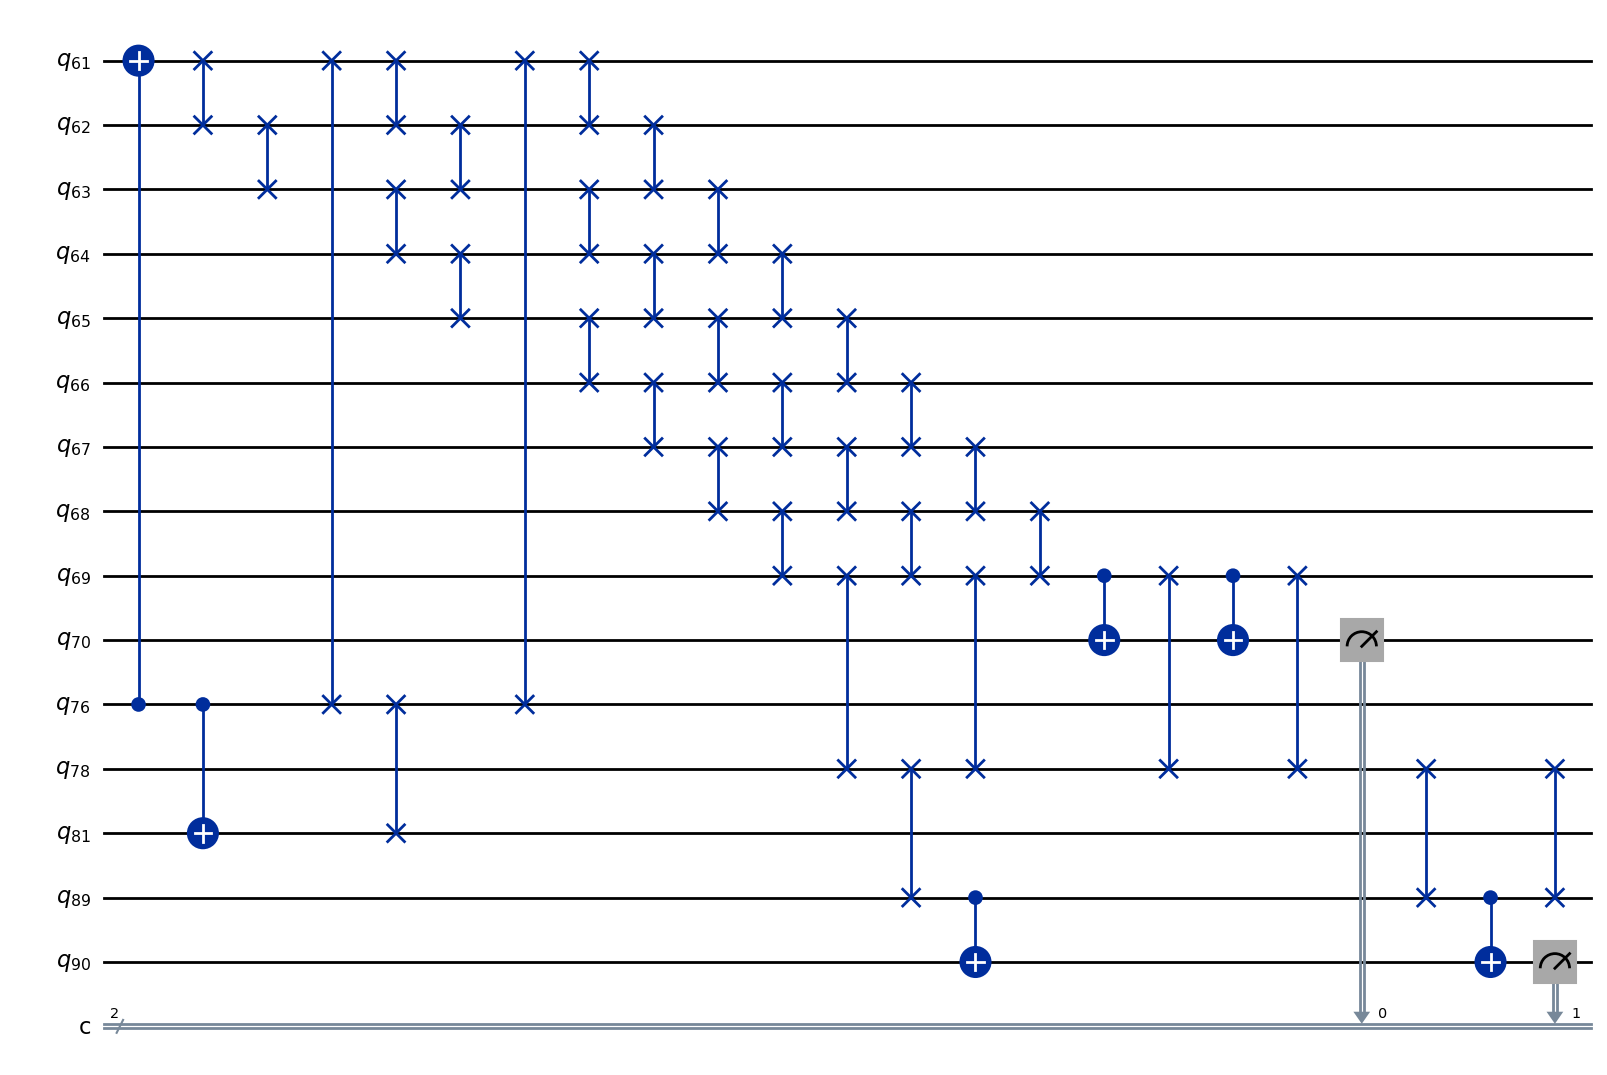

In [10]:
# ============================================================
# QUICK TEST: Single Route
# ============================================================

# Test a single route to verify circuit building
test_circuit = build_swapping_circuit(
    source=Node.A, 
    sink=Node.C, 
    initial_state='0',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits
)

print(f"Test circuit: Node A → Node C, initial state |0⟩")
print(f"  Qubits: {test_circuit.num_qubits}")
print(f"  Classical bits: {test_circuit.num_clbits}")
print(f"  Gate count: {test_circuit.size()}")
print(f"  Depth: {test_circuit.depth()}")

# Draw the circuit
test_circuit.draw('mpl', fold=-1, idle_wires=False)

In [11]:
# ============================================================
# QUICK TEST: Run Single Experiment
# ============================================================

test_counts, test_percentage = run_single_experiment(
    source=Node.A,
    sink=Node.C,
    initial_state='0',
    backend=backend,
    simulator=simulator,
    is_real_hardware=IS_REAL_HARDWARE,
    num_shots=1024
)

print(f"Test Run: Node A → Node C, state |0⟩")
print(f"  Syndrome counts: {test_counts}")
print(f"  Syndrome '00' rate: {test_percentage:.1f}%")

Test Run: Node A → Node C, state |0⟩
  Syndrome counts: {'00': 558, '01': 169, '10': 166, '11': 131}
  Syndrome '00' rate: 54.5%


In [12]:
# ============================================================
# RUN FULL EXPERIMENT: All States × All Routes
# ============================================================
# This cell runs the complete experiment suite.
# Warning: May take several minutes (120 circuit executions)

all_syndrome_matrices = run_full_experiment(
    initial_states=INITIAL_STATES,
    connection_tuples=CONNECTION_TUPLES,
    backend=backend,
    simulator=simulator,
    is_real_hardware=IS_REAL_HARDWARE,
    num_shots=NUM_SHOTS,
    num_nodes=NUM_NODES
)

RUNNING FULL EXPERIMENT
Backend:     ibm_fez (REAL)
States:      ['|0⟩', '|1⟩', '|+⟩', '|−⟩']
Routes:      30
Shots/route: 4096
Total runs:  120

>>> Initial State: |0⟩
--------------------------------------------------
  [ 1/30] A→B: 60.1%
  [ 2/30] A→C: 53.7%
  [ 3/30] A→D: 77.6%
  [ 4/30] A→E: 75.0%
  [ 5/30] A→F: 67.0%
  [ 6/30] B→A: 51.3%
  [ 7/30] B→C: 75.2%
  [ 8/30] B→D: 81.1%
  [ 9/30] B→E: 81.0%
  [10/30] B→F: 71.2%
  [11/30] C→A: 45.5%
  [12/30] C→B: 74.4%
  [13/30] C→D: 82.0%
  [14/30] C→E: 84.5%
  [15/30] C→F: 81.4%
  [16/30] D→A: 63.6%
  [17/30] D→B: 81.8%
  [18/30] D→C: 80.4%
  [19/30] D→E: 83.7%
  [20/30] D→F: 76.9%
  [21/30] E→A: 62.7%
  [22/30] E→B: 80.8%
  [23/30] E→C: 84.1%
  [24/30] E→D: 83.5%
  [25/30] E→F: 80.5%
  [26/30] F→A: 59.2%
  [27/30] F→B: 69.8%
  [28/30] F→C: 81.0%
  [29/30] F→D: 74.8%
  [30/30] F→E: 81.4%

  Summary: Avg=73.5%, Best=C→E (84.5%), Worst=C→A (45.5%)

>>> Initial State: |1⟩
--------------------------------------------------
  [ 1/30] A→B: 5

In [13]:
# ============================================================
# DISPLAY RESULTS: Summary Comparison
# ============================================================

print_full_comparison(all_syndrome_matrices, STATE_LABELS)

SYNDROME '00' PERCENTAGE - COMPARISON ACROSS ALL STATES

SUMMARY:
--------------------------------------------------------------------------------
State         Average      Best Route     Best %     Worst Route    Worst %
--------------------------------------------------------------------------------
|0⟩              73.5%             C→E      84.5%             C→A      45.5%
|1⟩              66.9%             D→E      79.3%             C→A      33.2%
|+⟩              70.5%             D→E      81.3%             C→A      39.8%
|−⟩              70.7%             D→E      81.6%             C→A      40.0%
--------------------------------------------------------------------------------


In [14]:
# ============================================================
# DISPLAY RESULTS: Detailed Matrices
# ============================================================

for state in INITIAL_STATES:
    print_matrix_summary(
        all_syndrome_matrices[state], 
        title=f"Matrix for {STATE_LABELS[state]}"
    )


Matrix for |0⟩
--------------------------------------------------
      →A    →B    →C    →D    →E    →F
A:     -   60.1 53.7 77.6 75.0 67.0
B:    51.3  -   75.2 81.1 81.0 71.2
C:    45.5 74.4  -   82.0 84.5 81.4
D:    63.6 81.8 80.4  -   83.7 76.9
E:    62.7 80.8 84.1 83.5  -   80.5
F:    59.2 69.8 81.0 74.8 81.4  -  

Statistics:
  Average: 73.5%
  Best:    C→E = 84.5%
  Worst:   C→A = 45.5%

Matrix for |1⟩
--------------------------------------------------
      →A    →B    →C    →D    →E    →F
A:     -   54.0 48.9 72.3 65.6 56.7
B:    35.5  -   66.8 73.2 73.6 65.3
C:    33.2 64.8  -   69.0 75.6 72.8
D:    68.2 77.2 71.8  -   79.3 68.0
E:    63.3 74.1 78.9 77.4  -   76.9
F:    58.2 66.2 73.6 70.0 76.0  -  

Statistics:
  Average: 66.9%
  Best:    D→E = 79.3%
  Worst:   C→A = 33.2%

Matrix for |+⟩
--------------------------------------------------
      →A    →B    →C    →D    →E    →F
A:     -   58.8 51.5 79.7 71.1 64.6
B:    44.7  -   69.2 79.4 76.5 71.8
C:    39.8 71.2  -   75.7 

/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_25707/2083243408.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.95])


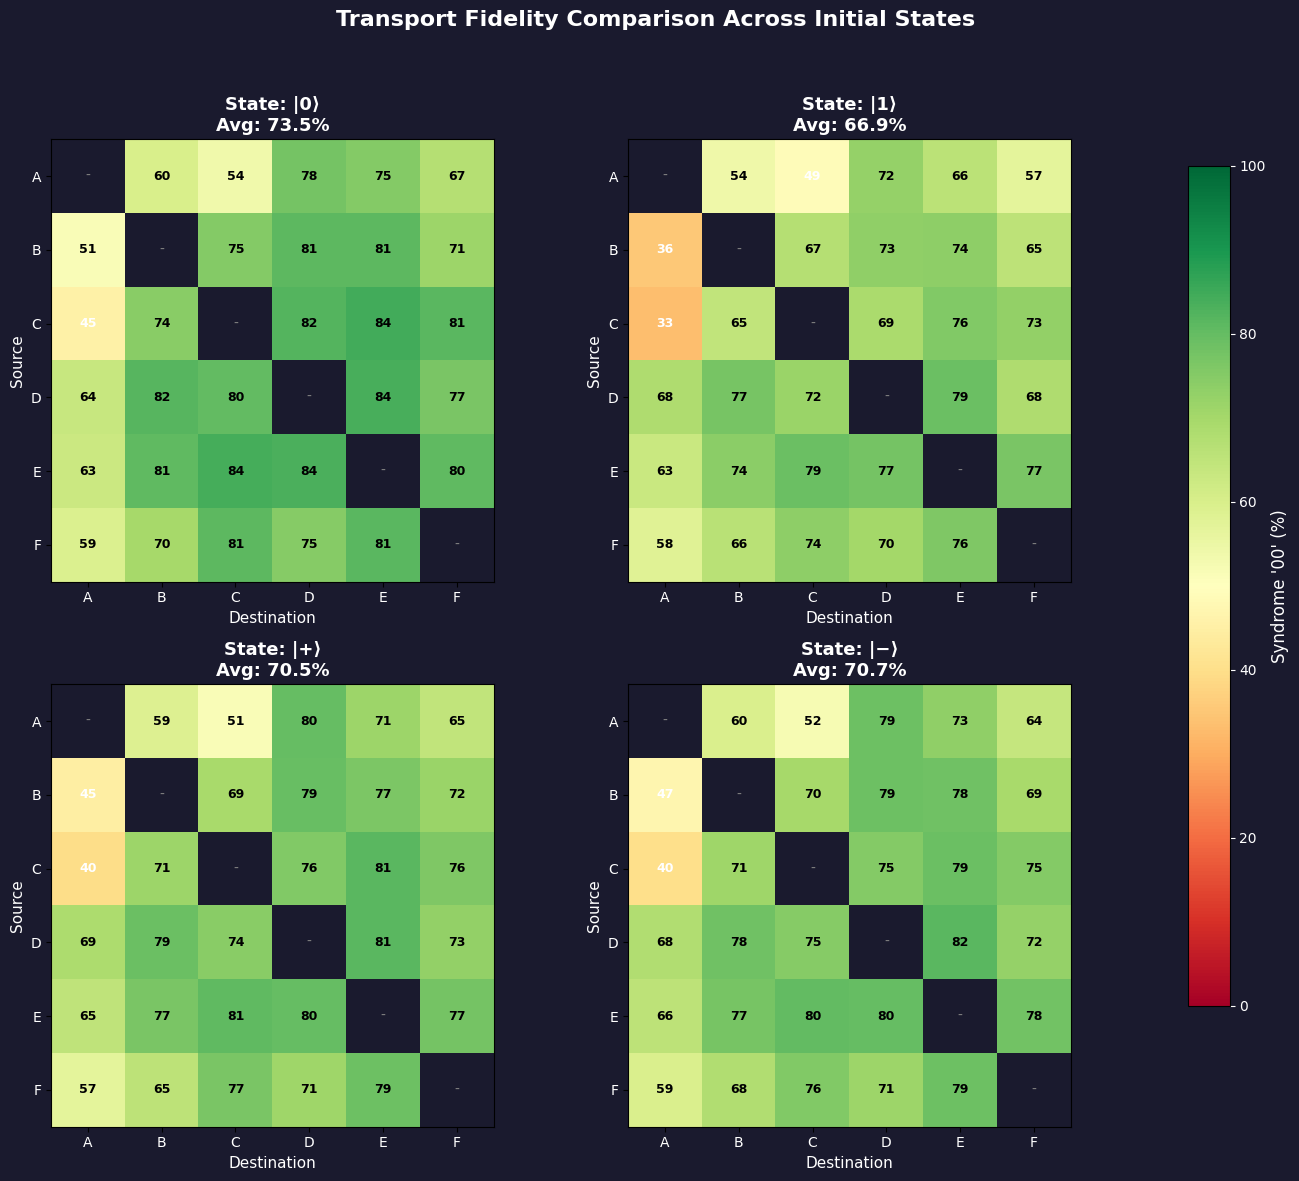

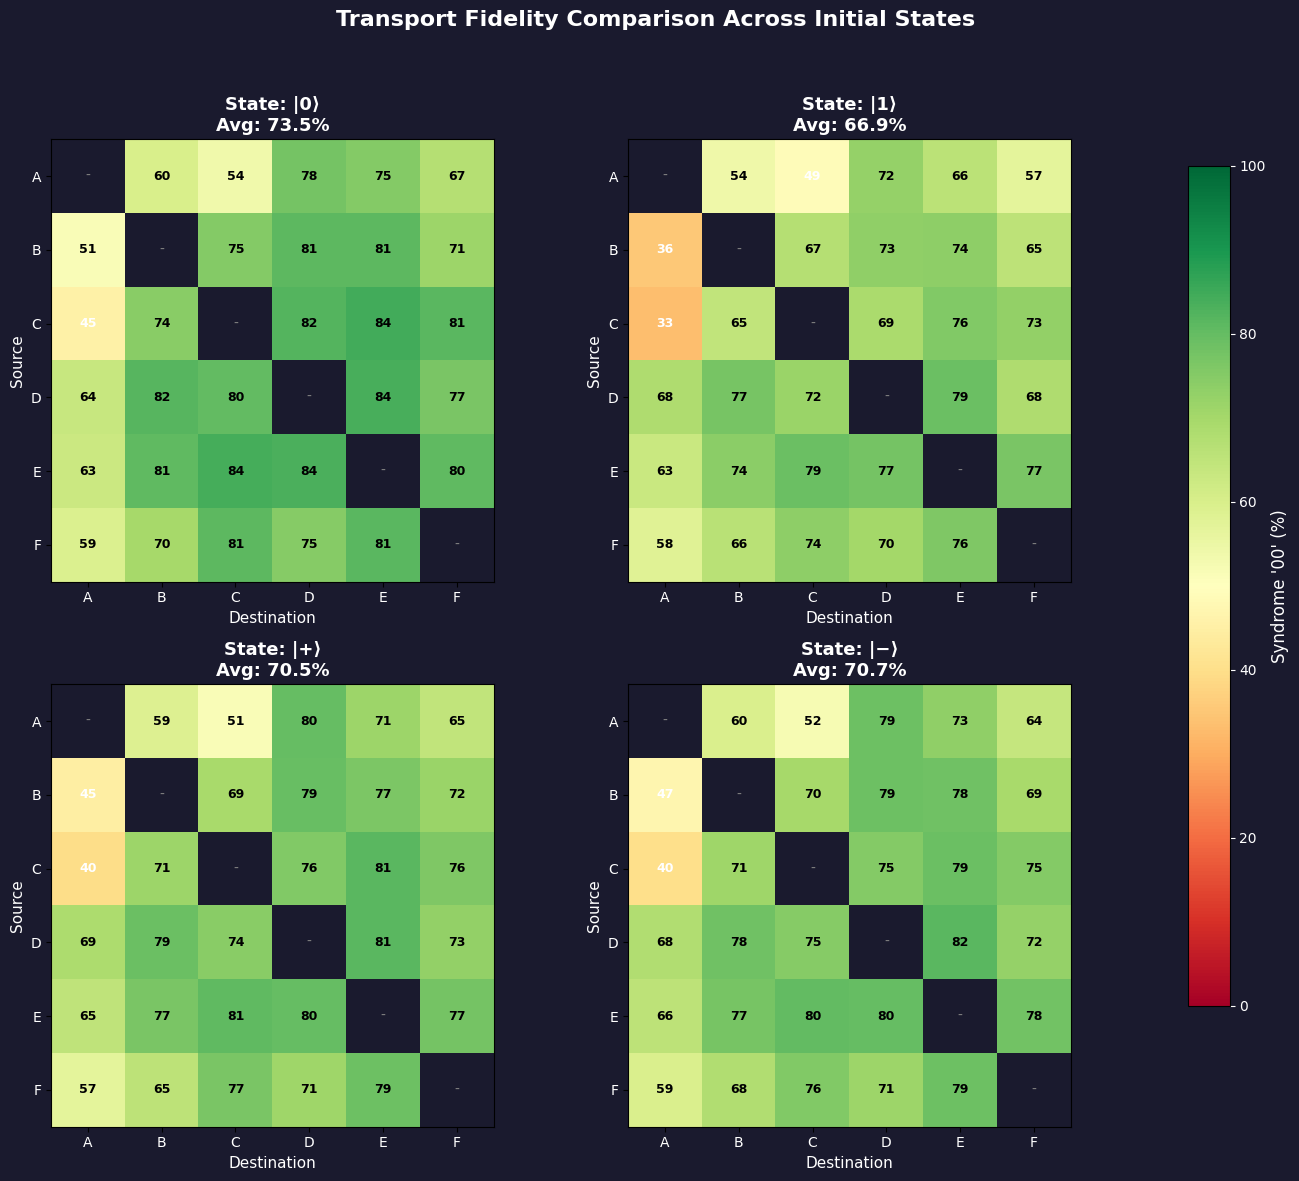

In [15]:
# ============================================================
# VISUALIZE: 2x2 Heatmap Comparison
# ============================================================

plot_all_states_comparison(all_syndrome_matrices, STATE_LABELS)

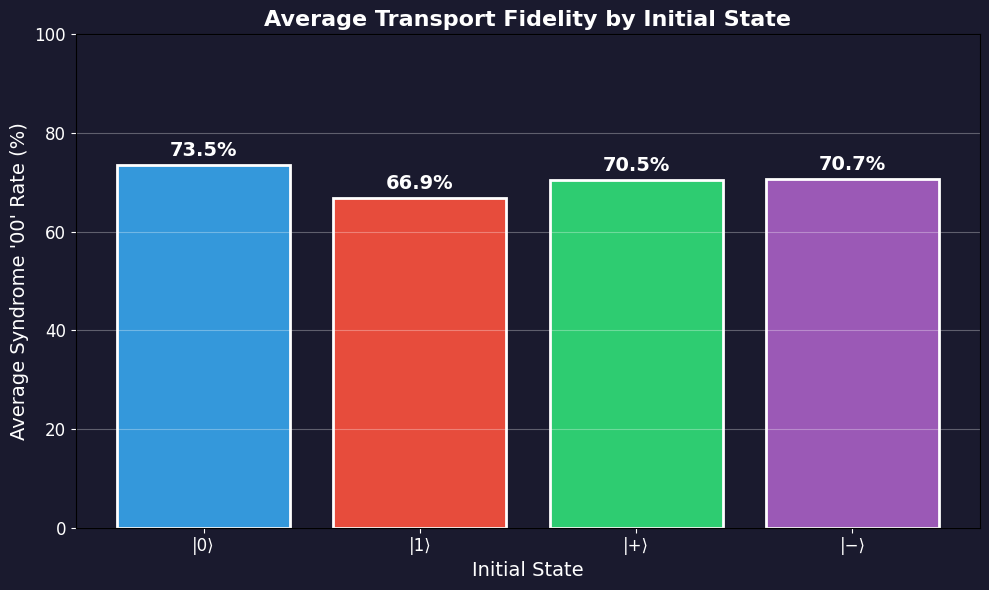


Key Insight:
  Best performing:  |0⟩ (73.5%)
  Worst performing: |1⟩ (66.9%)
  Difference: 6.6%


In [16]:
# ============================================================
# VISUALIZE: Bar Chart - Average by State
# ============================================================

plot_state_averages_bar(all_syndrome_matrices, STATE_LABELS)

# Print key insight
averages = [np.nanmean(all_syndrome_matrices[s]) for s in INITIAL_STATES]
best_state = INITIAL_STATES[np.argmax(averages)]
worst_state = INITIAL_STATES[np.argmin(averages)]

print("\nKey Insight:")
print(f"  Best performing:  {STATE_LABELS[best_state]} ({max(averages):.1f}%)")
print(f"  Worst performing: {STATE_LABELS[worst_state]} ({min(averages):.1f}%)")
print(f"  Difference: {max(averages) - min(averages):.1f}%")

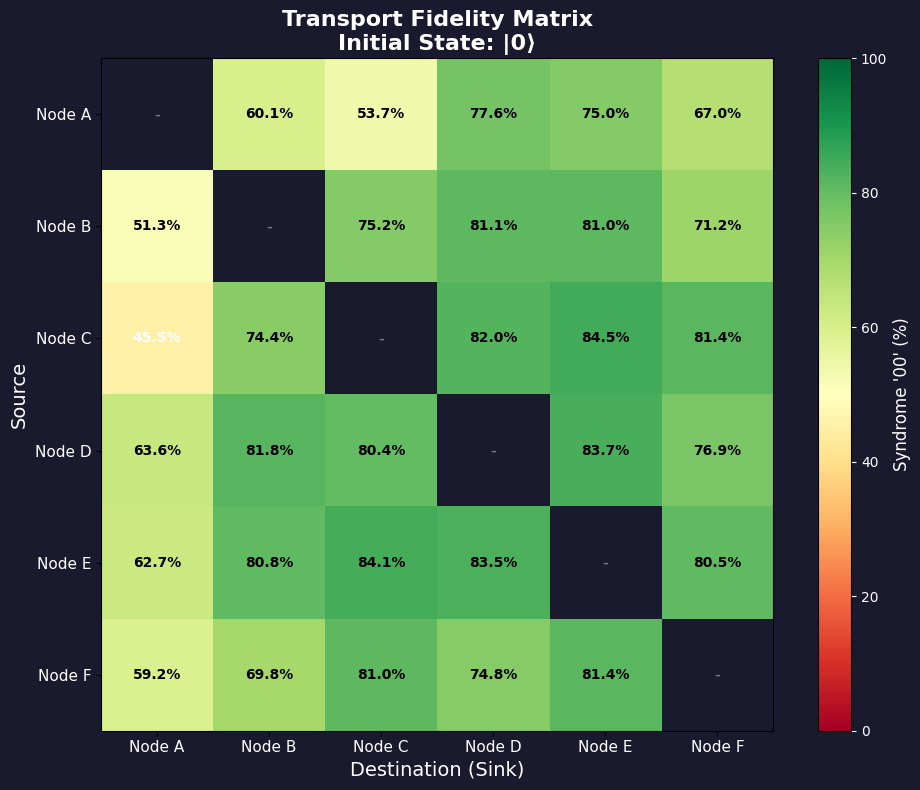

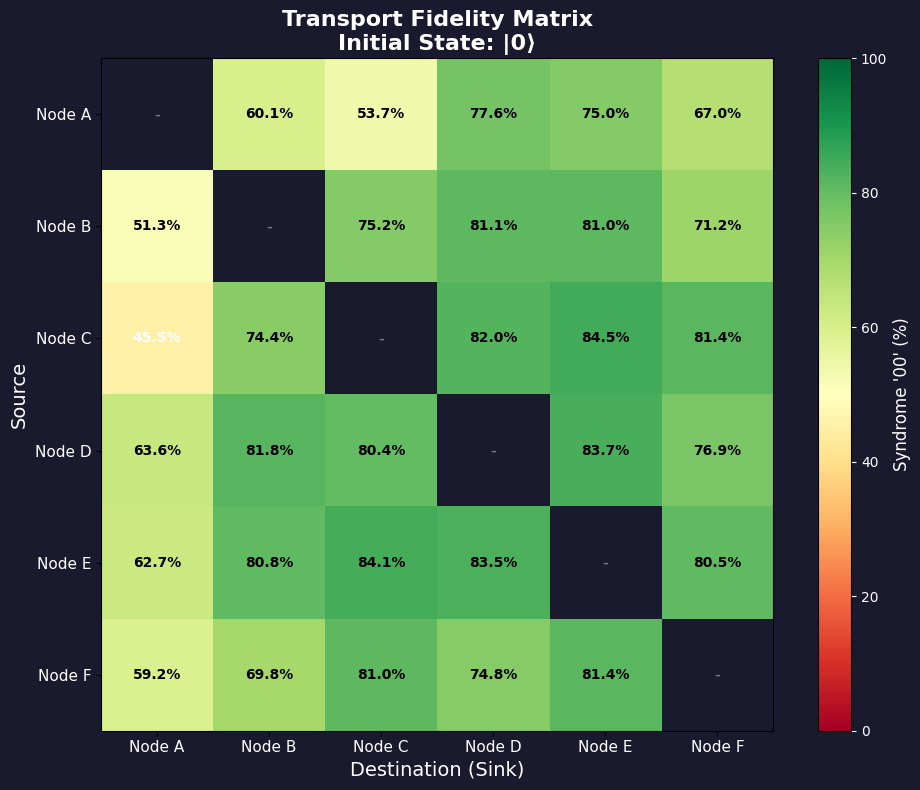

In [17]:
# ============================================================
# VISUALIZE: Single Matrix Heatmap
# ============================================================
# Plot a detailed view of one state (e.g., |0⟩)

plot_syndrome_matrix(
    all_syndrome_matrices['0'],
    title="Transport Fidelity Matrix",
    state_label=STATE_LABELS['0']
)

In [18]:
# ============================================================
# EXPORT: Save Results to JSON
# ============================================================

output_path = save_results_to_json(
    all_matrices=all_syndrome_matrices,
    backend_name=backend.name,
    num_shots=NUM_SHOTS,
    output_dir=OUTPUT_DIR,
    state_labels=STATE_LABELS,
    connection_tuples=CONNECTION_TUPLES
)

print(f"\nResults exported to: {output_path}")

Results saved to: ../outputs/syndromes/syndrome_results_20260115_054558.json
File size: 5.5 KB

Results exported to: ../outputs/syndromes/syndrome_results_20260115_054558.json
